In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv('tokyo_weather.csv')

df.head(1)

,Date,Average Temperature (°C),Highest Temperature (°C),Highest Temperature (°C) Datetime,Lowest Temperature (°C),Lowest Temperature (°C) Datetime,Total Precipitation (mm),Sunshine Duration (hours),Maximum Snow Depth (cm),Maximum Snow Depth (cm) Datetime,...,Maximum Wind Speed (m/s) Datetime,Maximum Wind Speed (m/s) Direction,Maximum Gust Speed (m/s),Maximum Gust Speed (m/s) Datetime,Maximum Gust Speed (m/s) Direction,Most Frequent Wind Direction (16-point compass),Average Vapor Pressure (hPa),Average Humidity (%),Minimum Relative Humidity (%),Minimum Relative Humidity (%) Datetime
0,2018/6/26,25.7,30.1,2018/6/26 12:38,22.3,2018/6/26 5:37,0.0,9.2,0,NaN,...,2018/6/26 20:04,S,12.4,2018/6/26 21:03,SSW,SE,24.7,75,56,2018/6/26 12:29


<Axes: xlabel='Date'>

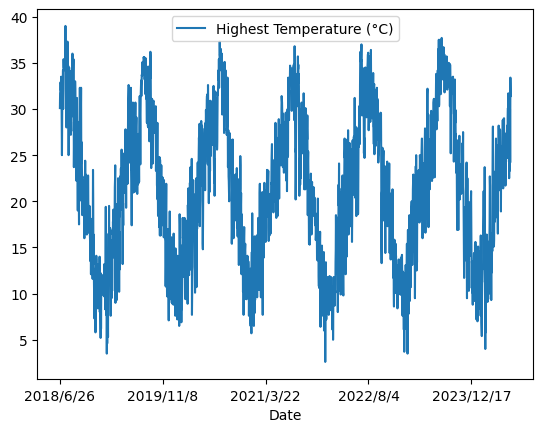

In [5]:
import matplotlib.pyplot as plt
df.plot(x = 'Date' , y = 'Highest Temperature (°C)', kind="line")


#df.plot(x = 'Date' , y = 'Average Temperature (°C)', kind="line")


#df.plot(x = 'Date' , y = 'Lowest Temperature (°C)', kind="line")






In [22]:
#splitting data

df_train = df.iloc[:-30].copy()
df_test = df.iloc[-30:].copy()









p-value: 0.10789068893351478


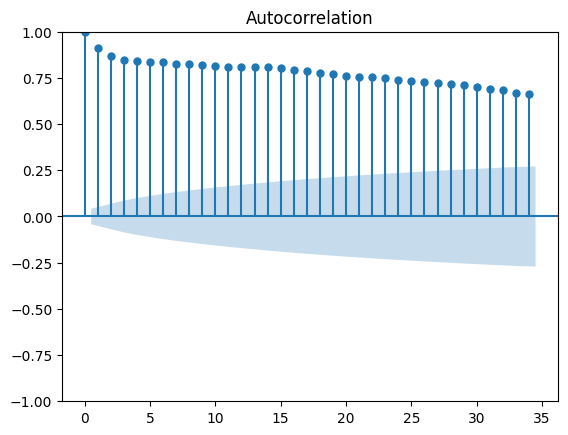

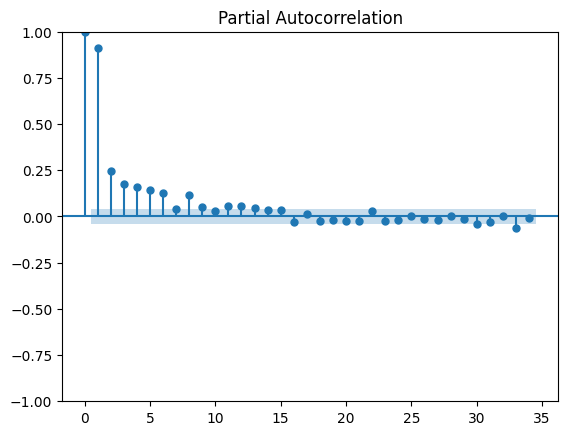

In [7]:
#arima assumptions (differences need to be stationary)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

acf_original = plot_acf(df_train['Highest Temperature (°C)'])

pacf_orginal = plot_pacf(df_train['Highest Temperature (°C)'])
adf_test = adfuller(df_train['Highest Temperature (°C)'])
print(f"p-value: {adf_test[1]}")
#plots show cooked and need to transfrom data to stationary using differencing

#make d = 1

p-value: 2.2677408979384672e-30
                                  SARIMAX Results                                   
Dep. Variable:     Highest Temperature (°C)   No. Observations:                 2163
Model:                       ARIMA(0, 1, 1)   Log Likelihood               -5563.976
Date:                      Wed, 29 Apr 2026   AIC                          11131.951
Time:                              19:10:03   BIC                          11143.309
Sample:                                   0   HQIC                         11136.105
                                     - 2163                                         
Covariance Type:                        opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.5608      0.016    -35.525      0.000      -0.592      -0.530
sigma2        10.0645      0.283     35.622      0.

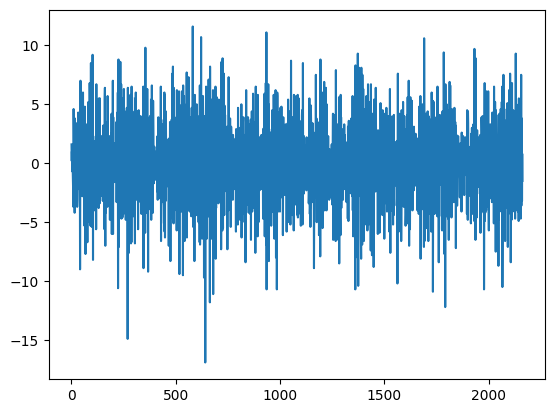

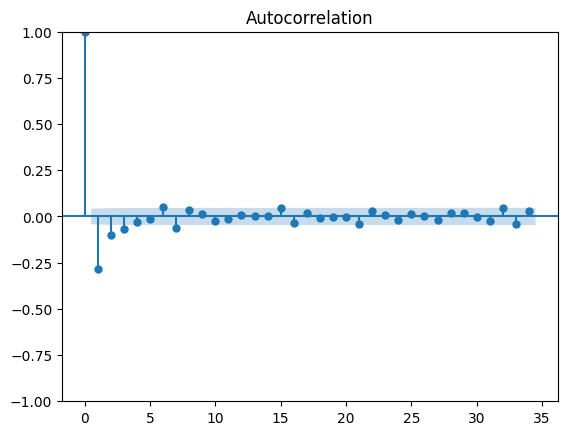

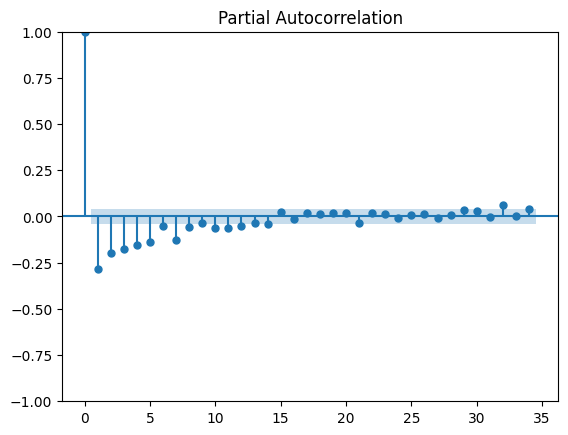

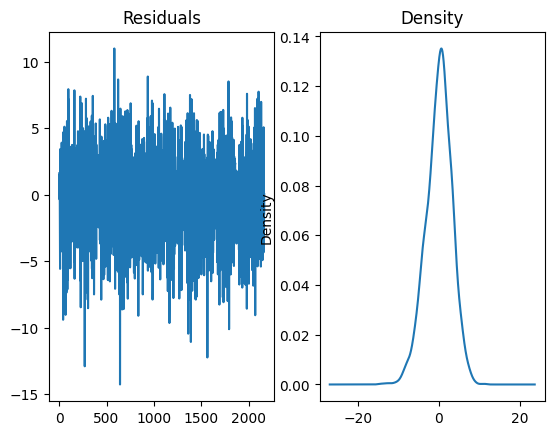

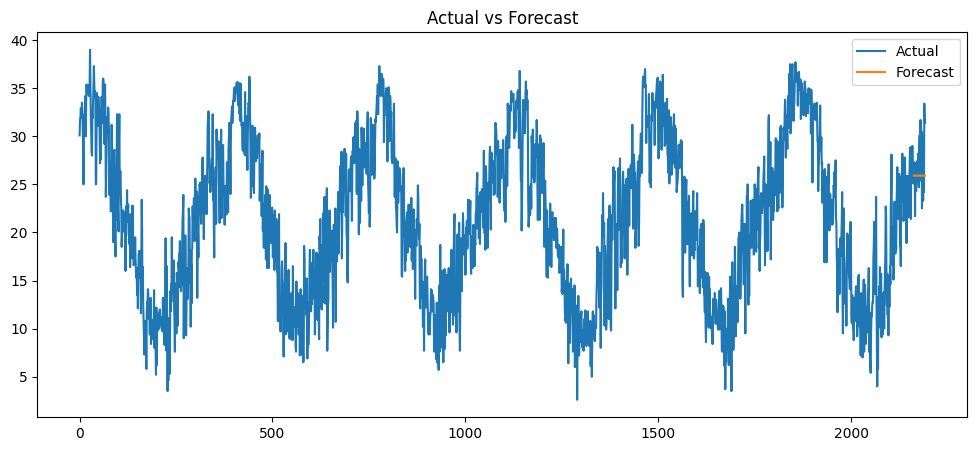

In [8]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
#data now good 

df_train_diff = df_train['Highest Temperature (°C)'].diff().dropna()
df_train_diff.plot()
adf_test = adfuller(df_train_diff)
print(f"p-value: {adf_test[1]}")


acf_original = plot_acf(df_train_diff)

pacf_orginal = plot_pacf(df_train_diff)


#so we say ARIMA(0,1,1)

model = ARIMA(df_train['Highest Temperature (°C)'], order=(0,1,1))
model_fit = model.fit()

print(model_fit.summary())

residuals = model_fit.resid[1:]

fig, ax = plt.subplots(1, 2)

residuals.plot(title='Residuals', ax=ax[0])
residuals.plot(title='Density', kind='kde', ax=ax[1])

plt.show()

forecast_test = model_fit.forecast(steps=len(df_test))

df['forecast_manual'] = [None] * len(df_train) + list(forecast_test)

# Plot only actual temperature and forecast
plt.figure(figsize=(12, 5))
df['Highest Temperature (°C)'].plot(label='Actual')
df['forecast_manual'].plot(label='Forecast')

plt.title("Actual vs Forecast")
plt.legend()
plt.show()

In [21]:
#something not right when were hand picking so gonna just use a library 
import numpy as np
import pandas as pd
import pmdarima as pm

from sklearn.metrics import mean_absolute_error, mean_squared_error

# -----------------------------
# Target variable
# -----------------------------

y_train = df_train["Highest Temperature (°C)"]
y_test = df_test["Highest Temperature (°C)"]

# -----------------------------
# Create yearly sine/cosine variables
# -----------------------------
# These represent the yearly temperature cycle.
# They help the model learn summer/winter seasonality.

if "Date" in df_train.columns:
    # Use actual day of year if Date column exists
    train_dates = pd.to_datetime(df_train["Date"])
    test_dates = pd.to_datetime(df_test["Date"])

    train_day = train_dates.dt.dayofyear
    test_day = test_dates.dt.dayofyear

    X_train = pd.DataFrame({
        "sin_year": np.sin(2 * np.pi * train_day / 365.25),
        "cos_year": np.cos(2 * np.pi * train_day / 365.25)
    })

    X_test = pd.DataFrame({
        "sin_year": np.sin(2 * np.pi * test_day / 365.25),
        "cos_year": np.cos(2 * np.pi * test_day / 365.25)
    })

else:
    # Backup version if there is no Date column
    t_train = np.arange(len(df_train))
    t_test = np.arange(len(df_train), len(df_train) + len(df_test))

    X_train = pd.DataFrame({
        "sin_year": np.sin(2 * np.pi * t_train / 365),
        "cos_year": np.cos(2 * np.pi * t_train / 365)
    })

    X_test = pd.DataFrame({
        "sin_year": np.sin(2 * np.pi * t_test / 365),
        "cos_year": np.cos(2 * np.pi * t_test / 365)
    })

# -----------------------------
# Fit auto ARIMA with external seasonal variables
# -----------------------------
# seasonal=False because the yearly seasonality is being added manually
# using sin_year and cos_year.
#
# m=365 is not needed when seasonal=False.

auto_arima = pm.auto_arima(
    y_train,
    X=X_train,
    stepwise=False,
    seasonal=False,
    suppress_warnings=True,
    error_action="ignore"
)

print(auto_arima.summary())

# -----------------------------
# Forecast test set
# -----------------------------
# Because the model was trained with X_train,
# you must also give X_test when predicting.

forecast_test = auto_arima.predict(
    n_periods=len(df_test),
    X=X_test
)

# -----------------------------
# Comparison table
# -----------------------------

comparison_table = pd.DataFrame({
    "Date": df_test["Date"].values if "Date" in df_test.columns else df_test.index,
    "Actual": y_test.values,
    "Predicted": forecast_test
})

comparison_table["Error"] = comparison_table["Actual"] - comparison_table["Predicted"]
comparison_table["Absolute Error"] = comparison_table["Error"].abs()

display(comparison_table)

# -----------------------------
# Accuracy
# -----------------------------

mae = mean_absolute_error(
    comparison_table["Actual"],
    comparison_table["Predicted"]
)

rmse = np.sqrt(mean_squared_error(
    comparison_table["Actual"],
    comparison_table["Predicted"]
))

print("MAE:", mae)
print("RMSE:", rmse)


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1593
Model:               SARIMAX(2, 0, 1)   Log Likelihood               -4017.125
Date:                Wed, 29 Apr 2026   AIC                           8046.250
Time:                        19:53:21   BIC                           8078.490
Sample:                             0   HQIC                          8058.224
                               - 1593                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sin_year      -4.1753      0.659     -6.333      0.000      -5.468      -2.883
cos_year      -9.2146      0.597    -15.422      0.000     -10.386      -8.044
ar.L1          1.4590      0.024     60.072      0.0

,Date,Actual,Predicted,Error,Absolute Error
1593,2022/11/5,17.3,19.831717,-2.531717,2.531717
1594,2022/11/6,18.4,19.202201,-0.802201,0.802201
1595,2022/11/7,18.2,18.820349,-0.620349,0.620349
1596,2022/11/8,22.2,18.552553,3.647447,3.647447
1597,2022/11/9,19.2,18.337508,0.862492,0.862492
1598,2022/11/10,21.8,18.147096,3.652904,3.652904
1599,2022/11/11,21.6,17.968437,3.631563,3.631563
1600,2022/11/12,21.8,17.795646,4.004354,4.004354
1601,2022/11/13,24.1,17.626047,6.473953,6.473953
1602,2022/11/14,18.8,17.458437,1.341563,1.341563


MAE: 2.0564833145459436
RMSE: 2.5985193911657443


In [23]:
import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pmdarima import auto_arima

# ---------------------------------------------------------
# Prepare the data
# ---------------------------------------------------------

# Get temperature column, remove missing values, and reset index
y = df["Highest Temperature (°C)"].dropna().reset_index(drop=True)

# ---------------------------------------------------------
# Create yearly sine/cosine seasonal variables
# ---------------------------------------------------------
# These help the ARIMA model understand yearly temperature seasonality.
#
# t = 0, 1, 2, 3, ... for each day in the dataset.
# sin_year and cos_year repeat every 365 days.

t = np.arange(len(y))

X = pd.DataFrame({
     "sin_year": np.sin(2 * np.pi * t / 365),
     "cos_year": np.cos(2 * np.pi * t / 365)
 })

# ---------------------------------------------------------
# Time series cross-validation setup
# ---------------------------------------------------------

# n_splits = 10 means we will do 10 separate train/test splits.
# Because test_size = 1, each split tests the model on 1 future day.
#
# Example:
# Fold 1: train days 1–90   -> test day 91
# Fold 2: train days 1–91   -> test day 92
# Fold 3: train days 1–92   -> test day 93
# ...
# Fold 10: train days 1–99  -> test day 100

n_splits = 10
tscv = TimeSeriesSplit(n_splits=n_splits, test_size=1)

predictions = []
actuals = []
orders = []

# ---------------------------------------------------------
# Cross-validation loop
# ---------------------------------------------------------

for fold, (train_index, test_index) in enumerate(tscv.split(y), start=1):

    # Training target values
    train = y.iloc[train_index]

    # Testing target value
    test = y.iloc[test_index]

    # External seasonal variables for the training period
    X_train = X.iloc[train_index]

    # External seasonal variables for the testing period
    X_test = X.iloc[test_index]

    print(f"\nFold {fold}")
    print("Training rows:", train_index[0], "to", train_index[-1])
    print("Testing row:", test_index[0])

    # -----------------------------------------------------
    # Fit auto ARIMA with yearly sine/cosine variables
    # -----------------------------------------------------
    # seasonal=False because we are manually giving the model
    # yearly seasonality using sin_year and cos_year.
    #
    # X=X_train gives the model the seasonal information.

    model = auto_arima(
        train,
        X=X_train,
        seasonal=False,
        stepwise=True,
        suppress_warnings=True,
        error_action="ignore"
    )

    # -----------------------------------------------------
    # Predict the next 1 day
    # -----------------------------------------------------
    # Because the model was trained with X_train,
    # we must also pass X_test when predicting.

    forecast = model.predict(
        n_periods=1,
        X=X_test
    )

    forecast_value = np.asarray(forecast)[0]

    predictions.append(forecast_value)
    actuals.append(test.iloc[0])
    orders.append(model.order)

# ---------------------------------------------------------
# Results table
# ---------------------------------------------------------

results = pd.DataFrame({
    "actual": actuals,
    "predicted": predictions,
    "error": np.array(actuals) - np.array(predictions),
    "absolute_error": np.abs(np.array(actuals) - np.array(predictions)),
    "arima_order": orders
})

# ---------------------------------------------------------
# Accuracy
# ---------------------------------------------------------

mae = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mean_squared_error(actuals, predictions))

print("\nCross-validation results:")
print(results)

print("\nMAE:", mae)
print("RMSE:", rmse)





Fold 1
Training rows: 0 to 2182
Testing row: 2183

Fold 2
Training rows: 0 to 2183
Testing row: 2184

Fold 3
Training rows: 0 to 2184
Testing row: 2185

Fold 4
Training rows: 0 to 2185
Testing row: 2186

Fold 5
Training rows: 0 to 2186
Testing row: 2187

Fold 6
Training rows: 0 to 2187
Testing row: 2188

Fold 7
Training rows: 0 to 2188
Testing row: 2189

Fold 8
Training rows: 0 to 2189
Testing row: 2190

Fold 9
Training rows: 0 to 2190
Testing row: 2191

Fold 10
Training rows: 0 to 2191
Testing row: 2192

Cross-validation results:
   actual  predicted     error  absolute_error arima_order
0    30.5  28.822721  1.677279        1.677279   (1, 1, 1)
1    22.5  29.774477 -7.274477        7.274477   (1, 1, 1)
2    29.5  25.869460  3.630540        3.630540   (1, 1, 1)
3    28.4  29.238954 -0.838954        0.838954   (1, 1, 1)
4    23.3  28.757142 -5.457142        5.457142   (1, 1, 1)
5    30.0  26.245050  3.754950        3.754950   (1, 1, 1)
6    24.2  29.475661 -5.275661        5.275661   